In [1]:
## -- Check for 3rd party libraries (tpu) --
try:
    import catboost as cgb
except:
    !uv pip install catboost
    import catboost as cgb

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'GPU: Tesla T4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


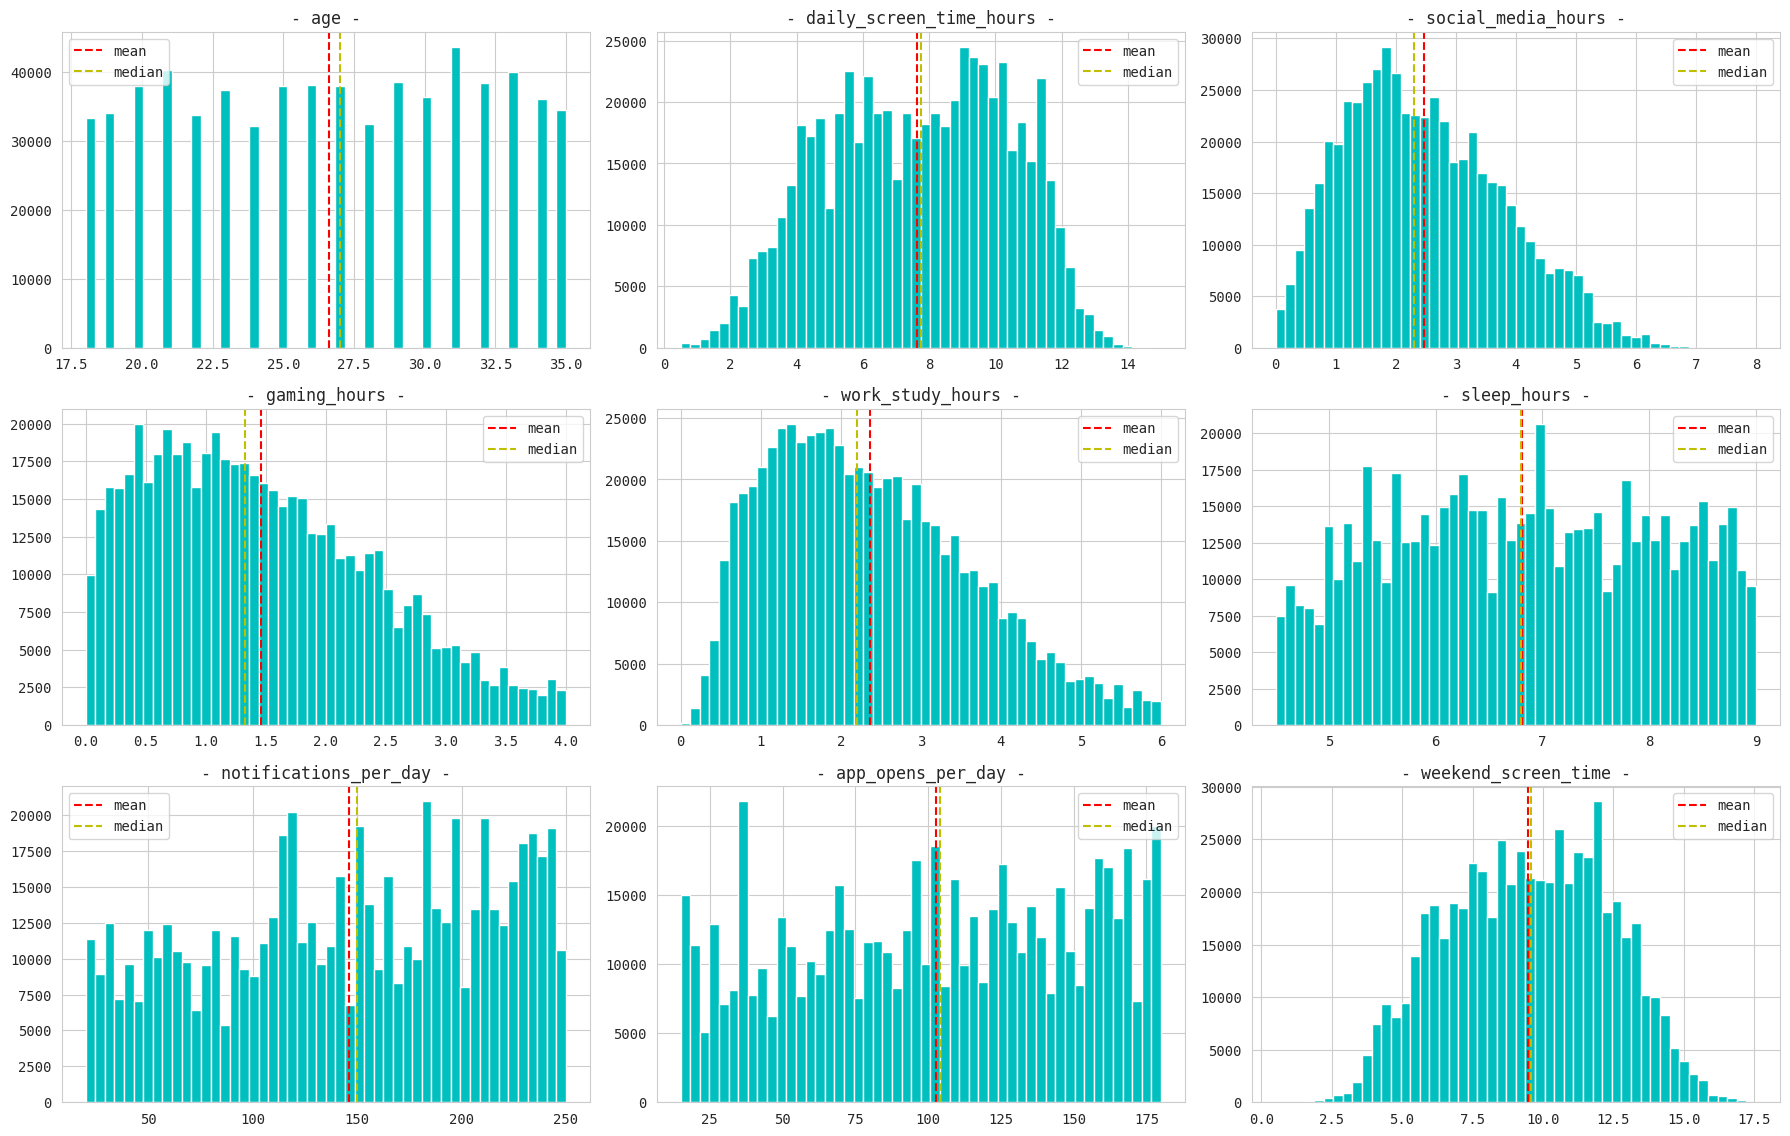

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    # ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         # pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.style.background_gradient()

,Train,Test
age,18,18
daily_screen_time_hours,1389,1349
social_media_hours,721,703
gaming_hours,401,401
work_study_hours,600,601
sleep_hours,451,451
notifications_per_day,231,231
app_opens_per_day,166,166
weekend_screen_time,1437,1404
gender,3,3


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         # orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
# orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [15]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
# ## -- Frequency encoding --
# FREQ_COLS = []

# print(f"\nCreating frequencies... ", end='')
# for col in NUMS: # 'Position_Change'
#     freq = pd.concat([train[col], test[col]]).value_counts(normalize=True) # orig[col], 
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test]: # , orig
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     FREQ_COLS.append(n)

# print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")
# train[FREQ_COLS]

In [17]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(CATS, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(CATS, DIGITS)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     # orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")

In [18]:
# ## -- Arithmetic interactions --
# for df in [train, test]: # , orig
#     # df["_weeknd_X_daily"] = (
#     #                                     df["weekend_screen_time"] + \
#     #                                     df["daily_screen_time_hours"]).astype('float32')
#     # df["_gaming_X_daily_X_social"] = (
#     #                                     df["gaming_hours"] + \
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"]).astype('float32')
#     df["_daily_X_social_X_weekend"] = (
#                                         df["daily_screen_time_hours"] + \
#                                         df["social_media_hours"] + \
#                                         df["weekend_screen_time"]).astype("float32")
#     # df["_daily_X_social_X_work_/_sleep"] = ((
#     #                                     df["daily_screen_time_hours"] + \
#     #                                     df["social_media_hours"] + \
#     #                                     df["work_study_hours"]) / (df["sleep_hours"]+1e-8)).astype('float32')

# ARITHMETIC_COLS = [
#     # "_weeknd_X_daily",
#     # "_gaming_X_daily_X_social",
#     "_daily_X_social_X_weekend",
#     # "_daily_X_social_X_work_/_sleep",
#     # '_LapTime (s)_*_Cum_Deg_abs',
#     # '_LapTime (s)_/_Cum_Deg_abs',
# ]

# print(f"Total Arithmetic interactions: {len(ARITHMETIC_COLS)}")

# train[ARITHMETIC_COLS]

In [19]:
# ## -- Cyclic encoding --
# for df in [train, test]:
#     for p in [8, 12, 24]:
#         df[f"sleep_hours_sin_{p}"] = np.sin(2 * np.pi * df["sleep_hours"] / p).astype("float32")
#         df[f"sleep_hours_cos_{p}"] = np.cos(2 * np.pi * df["sleep_hours"] / p).astype("float32")

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [21]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [22]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE,
#     target=TARGET,
#     aggs=["mean", "count", "std"], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# train

In [23]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     # orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize -- 
#     combined  = pd.concat([train[n], test[n]]) # , orig[n]
#     cat_v = combined.factorize()[0]
#     # cat_v = pd.Series(cat_v).astype('category')
#     train[n] = cat_v[:len(train)].astype('int32')
#     test[n]  = cat_v[len(train):len(train)+len(test)].astype('int32')
#     # orig[n]  = __[len(train)+len(test):].astype('int32')

# del combined, cat_v
# print(f"Nums to Cats: {len(CATS_2)}")

# CATS_2

In [24]:
## -- Factorize combined data --
for c in CATS:
    combined = pd.concat([train[c], test[c], orig[c]])
    cat_v = combined.factorize()[0]
    # cat_v = pd.Series(cat_v).astype('category')
    train[c] = cat_v[:len(train)]
    test[c]  = cat_v[len(train):len(train)+len(test)]
    orig[c]  = cat_v[len(train)+len(test):]

del combined, cat_v
print("Label encoding complete!")

Label encoding complete!


In [25]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 12


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1,2,0,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,2,0,0,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,2,-1,-1,1


# ML TRAINING

In [26]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kfold, cat_cols,
               use_orig=False, early_stop=100, print_every=200):
    print(f"\n===== Starting CV: {model_name} =====")
    t0 = time()

    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []
    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n##### FOLD {idx}/{kfold.n_splits}", end=" | ")

        ## -- Split data for the current fold
        X_train, X_valid = X.loc[train_idx], X.loc[val_idx]
        y_train, y_valid = y.loc[train_idx], y.loc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        ## -- OPTION B: TE Merge original data --
        if use_orig:
            X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
                orig,
                X_train,
                X_valid,
                X_test,
                features=BASE,
                target=TARGET,
                aggs=["mean", "count", "std"], # mean, median, count, std, skew, nunique, max, min
                fill_nan=True,
            )

        # ## -- TE Opt1. -> Using CUSTOM -- LOW_100_UNIQUE, TOP_100_UNIQUE
        # te_enc  = TargetEncoder(CATS_2, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        all_categorical = cat_cols.copy()
        combined = pd.concat([X_train, X_valid, X_test])

        for c in all_categorical:
            combined[c] = combined[c].astype(str)

        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"shape: {X_train.shape}")

        dtrain = cgb.Pool(data=X_train, label=y_train, cat_features=all_categorical)
        dval   = cgb.Pool(data=X_valid, label=y_valid, cat_features=all_categorical)
        dtest  = cgb.Pool(data=X_test, cat_features=all_categorical)

        model = cgb.train(
            dtrain=dtrain,
            params=params,
            num_boost_round=10_000,
            eval_set=dval,
            early_stopping_rounds=early_stop,
            verbose=print_every,
        )

        feat_importances.append(model.get_feature_importance(prettified=True))

        # Predict on validation and test sets
        oof_preds[val_idx] = model.predict(dval, prediction_type='Probability')[:, 1].ravel()
        test_preds += model.predict(dtest, prediction_type='Probability')[:, 1].ravel() / kfold.n_splits

        # Calculate and print fold score
        fold_score = roc_auc_score(y_valid.to_numpy(), oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']} • Fold {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        # Clean up memory
        del dtrain, dval, dtest
        # gc.collect()

    # # Average test predictions
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {score:.6f}")

    ## -- Out-of-fold AUC --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)
    
    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_score}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{((time() - t0) / 60):.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'importances': feat_importances,
        'val_data': [X_valid, y_valid],
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [27]:
VER = "cat_origCV_"
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS # + CATS_2

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0,0,0,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,1,0,0,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,1,1,1,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,2,1,-1,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0,-1,0,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,1,2,0,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,2,0,0,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,2,-1,-1,1


In [28]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = 'Trial_'
# COMPILER = []

# OUT_LOOP = [0.5, 1.0]
# INN_LOOP = [4.0]
# p_name   = ['BT', 'L1']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'boosting_type': value,
#             # ---------------------------------
#             'grow_policy': 'SymmetricTree',
#             # ---------------------------------
#             'bootstrap_type': 'Bayesian',
#             'bagging_temperature': outer,
#             # 'random_strength': 1.0,
#             # ---------------------------------
#             'loss_function': 'Logloss',
#             'eval_metric': 'AUC',
#             'learning_rate': 0.05,
#             # 'depth': 6,
#             # 'l2_leaf_reg': REGULATE,
#             'thread_count': os.cpu_count(),
#             'allow_writing_files': False,
#             'random_state': SEED,
#             'verbose': 0,
#             'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=CATS+DIGITS+['cat_tenure'],
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} models ======\n")

In [29]:
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'score':
#                 # print(k, y)
#                 all_model_scores[model_name] = value

# plt.figure(figsize=(20, 6))
# # pd.Series(all_model_scores).plot(marker='o')
# sns.lineplot(all_model_scores, marker='o')
# plt.title('CATBoost Scores', fontweight='semibold')

# for i, score in enumerate(all_model_scores.values()):
#     plt.text(float(i), score-5e-8, score, ha='right', va='baseline')

# plt.tick_params('x', rotation=45, reset=True)
# plt.show()

In [30]:
LR = 0.03
# L2_REG = 2.5
EARLY_STOP   = 100
PRINT_STEPS  = 1000
USE_ORIGINAL = True

In [31]:
## ========================== BAYESIAN 
bayes_params = {
    'boosting_type': 'Plain',
    'grow_policy': 'SymmetricTree',
    'bootstrap_type': 'Bayesian',
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 8,
    # ---------------------------------
    # 'bagging_temperature': 0.2,
    # 'random_strength': 0.8,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = VER+"bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bayes_params,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)

# ==================================================
# 5-FOLD CV: cat_bayes
# ==================================================
#  • Fold 1 AUC: 0.966181
#  • Fold 2 AUC: 0.966927
#  • Fold 3 AUC: 0.967223
#  • Fold 4 AUC: 0.967437
#  • Fold 5 AUC: 0.966501
# -------------------------------------------------|
# Overall AUC: 0.966853
# Average AUC: 0.966854 ± 0.000460
# -------------------------------------------------|
# 14.42 mins


===== Starting CV: cat_origCV_bayes =====

##### FOLD 1/5 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

shape: (553095, 48)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9167113	best: 0.9167113 (0)	total: 196ms	remaining: 32m 37s
1000:	test: 0.9597491	best: 0.9597491 (1000)	total: 31.8s	remaining: 4m 46s
2000:	test: 0.9618295	best: 0.9618295 (2000)	total: 1m 3s	remaining: 4m 12s
3000:	test: 0.9626924	best: 0.9626924 (3000)	total: 1m 35s	remaining: 3m 41s
4000:	test: 0.9630942	best: 0.9630942 (3999)	total: 2m 7s	remaining: 3m 10s
5000:	test: 0.9633715	best: 0.9633715 (5000)	total: 2m 39s	remaining: 2m 39s
6000:	test: 0.9635562	best: 0.9635562 (6000)	total: 3m 11s	remaining: 2m 7s
7000:	test: 0.9636652	best: 0.9636652 (7000)	total: 3m 43s	remaining: 1m 35s
8000:	test: 0.9637618	best: 0.9637620 (7997)	total: 4m 14s	remaining: 1m 3s
bestTest = 0.9638108611
bestIteration = 8755
Shrink model to first 8756 iterations.
 • Fold 1 AUC: 0.963811

##### FOLD 2/5 | 

...

0:	test: 0.9194384	best: 0.9194384 (0)	total: 47.4ms	remaining: 7m 54s
1000:	test: 0.9608254	best: 0.9608254 (1000)	total: 31.9s	remaining: 4m 46s
2000:	test: 0.9628683	best: 0.9628683 (2000)	total: 1m 3s	remaining: 4m 13s
3000:	test: 0.9636810	best: 0.9636810 (3000)	total: 1m 34s	remaining: 3m 41s
4000:	test: 0.9641184	best: 0.9641184 (4000)	total: 2m 6s	remaining: 3m 10s
5000:	test: 0.9643984	best: 0.9643984 (5000)	total: 2m 38s	remaining: 2m 38s
6000:	test: 0.9645880	best: 0.9645880 (6000)	total: 3m 10s	remaining: 2m 6s
7000:	test: 0.9647349	best: 0.9647358 (6997)	total: 3m 42s	remaining: 1m 35s
8000:	test: 0.9648483	best: 0.9648508 (7969)	total: 4m 14s	remaining: 1m 3s
9000:	test: 0.9649255	best: 0.9649259 (8991)	total: 4m 47s	remaining: 31.9s
bestTest = 0.9649421573
bestIteration = 9212
Shrink model to first 9213 iterations.
 • Fold 4 AUC: 0.964942

##### FOLD 5/5 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

shape: (553096, 48)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9173439	best: 0.9173439 (0)	total: 48.1ms	remaining: 8m
1000:	test: 0.9596182	best: 0.9596182 (1000)	total: 32.3s	remaining: 4m 50s
2000:	test: 0.9617541	best: 0.9617541 (2000)	total: 1m 4s	remaining: 4m 18s
3000:	test: 0.9625661	best: 0.9625661 (3000)	total: 1m 36s	remaining: 3m 45s
4000:	test: 0.9630476	best: 0.9630476 (4000)	total: 2m 9s	remaining: 3m 13s
5000:	test: 0.9633557	best: 0.9633557 (5000)	total: 2m 41s	remaining: 2m 41s
6000:	test: 0.9635963	best: 0.9635966 (5999)	total: 3m 13s	remaining: 2m 8s
7000:	test: 0.9637541	best: 0.9637541 (7000)	total: 3m 45s	remaining: 1m 36s
8000:	test: 0.9638719	best: 0.9638728 (7977)	total: 4m 17s	remaining: 1m 4s
9000:	test: 0.9639554	best: 0.9639554 (9000)	total: 4m 49s	remaining: 32.2s
9999:	test: 0.9640237	best: 0.9640256 (9968)	total: 5m 22s	remaining: 0us
bestTest = 0.9640256166
bestIteration = 9968
Shrink model to first 9969 iterations.
 • Fold 5 AUC: 0.964026

5-FOLD CV: cat_origCV_bayes
 • Fold 1 AUC: 0.963811
 • Fold 2 A

In [32]:
# 9643, 9650

In [33]:
# ## =========================== MVS -- OOM issues
# mvs_params = {
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     # 'learning_rate': LR,
#     # ---------------------------------
#     # 'boosting_type': 'Plain',
#     # ---------------------------------
#     'grow_policy': 'Depthwise',
#     # ---------------------------------
#     'bootstrap_type': 'MVS',
#     # 'min_data_in_leaf': 2,
#     # 'subsample': 0.8, # auto 0.8 for 'MVS'
#     # ---------------------------------
#     # 'depth': 6,
#     # 'l2_leaf_reg': L2_REG,
#     'random_state': CFG['SEED'],
#     'verbose': 0,
#     'thread_count': -1,
#     'allow_writing_files': False,
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# n = VER+"cat_mvs"

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=mvs_params,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kfold=skf,
#     cat_cols=ALL_CATS,
#     use_orig=USE_ORIGINAL,
#     early_stop=EARLY_STOP,
#     print_every=PRINT_STEPS,
# )

In [34]:
## =========================== BERNOULLI
bern_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 6,
    # ---------------------------------
    'boosting_type': 'Plain',
    'grow_policy': 'Depthwise',
    'bootstrap_type': 'Bernoulli',
    # ---------------------------------
    # 'subsample': 0.8, # auto 0.66
    # 'colsample_bylevel': 0.7,
    # 'min_data_in_leaf': 20,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = VER + "bern"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=bern_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS
)


===== Starting CV: cat_origCV_bern =====

##### FOLD 1/5 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

shape: (553095, 48)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9252292	best: 0.9252292 (0)	total: 145ms	remaining: 24m 6s
1000:	test: 0.9620050	best: 0.9620050 (1000)	total: 24.9s	remaining: 3m 43s
2000:	test: 0.9634290	best: 0.9634290 (2000)	total: 50.1s	remaining: 3m 20s
3000:	test: 0.9638938	best: 0.9638939 (2999)	total: 1m 15s	remaining: 2m 55s
4000:	test: 0.9640726	best: 0.9640726 (4000)	total: 1m 40s	remaining: 2m 31s
bestTest = 0.9640865326
bestIteration = 4226
Shrink model to first 4227 iterations.
 • Fold 1 AUC: 0.964087

##### FOLD 2/5 | 

...

0:	test: 0.9258041	best: 0.9258041 (0)	total: 54.8ms	remaining: 9m 8s
1000:	test: 0.9631855	best: 0.9631855 (1000)	total: 25.6s	remaining: 3m 50s
2000:	test: 0.9646205	best: 0.9646215 (1999)	total: 51s	remaining: 3m 24s
3000:	test: 0.9650728	best: 0.9650735 (2999)	total: 1m 16s	remaining: 2m 58s
4000:	test: 0.9652890	best: 0.9652901 (3948)	total: 1m 41s	remaining: 2m 32s
bestTest = 0.9653482437
bestIteration = 4626
Shrink model to first 4627 iterations.
 • Fold 4 AUC: 0.965348

##### FOLD 5/5 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

shape: (553096, 48)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9250372	best: 0.9250372 (0)	total: 44.1ms	remaining: 7m 20s
1000:	test: 0.9619989	best: 0.9619989 (1000)	total: 25.5s	remaining: 3m 49s
2000:	test: 0.9635416	best: 0.9635416 (2000)	total: 51.2s	remaining: 3m 24s
3000:	test: 0.9640592	best: 0.9640608 (2993)	total: 1m 16s	remaining: 2m 58s
4000:	test: 0.9642621	best: 0.9642631 (3989)	total: 1m 42s	remaining: 2m 33s
5000:	test: 0.9643735	best: 0.9643766 (4949)	total: 2m 8s	remaining: 2m 8s
bestTest = 0.9643853903
bestIteration = 5118
Shrink model to first 5119 iterations.
 • Fold 5 AUC: 0.964385

5-FOLD CV: cat_origCV_bern
 • Fold 1 AUC: 0.964087
 • Fold 2 AUC: 0.964648
 • Fold 3 AUC: 0.964820
 • Fold 4 AUC: 0.965348
 • Fold 5 AUC: 0.964385
-------------------------------------------------|
Overall AUC: 0.964655
Average AUC: 0.964658 ± 0.000425
-------------------------------------------------|
12.22 mins



In [35]:
## =========================== LOSSGUIDE

loss_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'l2_leaf_reg': L2_REG,
    # 'depth': 6,
    # ---------------------------------
    'boosting_type': 'Plain',
    'grow_policy': 'Lossguide',
    # ---------------------------------
    # 'max_leaves': 32,
    # 'min_data_in_leaf': 2,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = VER+"loss"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=loss_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_origCV_loss =====

##### FOLD 1/5 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

shape: (553095, 48)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9213720	best: 0.9213720 (0)	total: 54.5ms	remaining: 9m 5s
1000:	test: 0.9618353	best: 0.9618353 (1000)	total: 39.2s	remaining: 5m 51s
2000:	test: 0.9632273	best: 0.9632273 (2000)	total: 1m 21s	remaining: 5m 25s
3000:	test: 0.9637221	best: 0.9637231 (2996)	total: 2m 1s	remaining: 4m 43s
4000:	test: 0.9639812	best: 0.9639812 (4000)	total: 2m 40s	remaining: 4m 1s
5000:	test: 0.9641316	best: 0.9641331 (4996)	total: 3m 17s	remaining: 3m 17s
6000:	test: 0.9642230	best: 0.9642232 (5998)	total: 3m 57s	remaining: 2m 37s
bestTest = 0.9642862678
bestIteration = 6809
Shrink model to first 6810 iterations.
 • Fold 1 AUC: 0.964286

##### FOLD 2/5 | 

...

0:	test: 0.9222380	best: 0.9222380 (0)	total: 46.2ms	remaining: 7m 41s
1000:	test: 0.9630474	best: 0.9630474 (1000)	total: 38.1s	remaining: 5m 42s
2000:	test: 0.9644088	best: 0.9644088 (2000)	total: 1m 18s	remaining: 5m 12s
3000:	test: 0.9649006	best: 0.9649006 (3000)	total: 1m 58s	remaining: 4m 35s
4000:	test: 0.9651521	best: 0.9651522 (3999)	total: 2m 39s	remaining: 3m 59s
5000:	test: 0.9653002	best: 0.9653002 (5000)	total: 3m 19s	remaining: 3m 19s
bestTest = 0.9653508663
bestIteration = 5565
Shrink model to first 5566 iterations.
 • Fold 4 AUC: 0.965351

##### FOLD 5/5 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

shape: (553096, 48)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9216940	best: 0.9216940 (0)	total: 53ms	remaining: 8m 49s
1000:	test: 0.9619010	best: 0.9619011 (999)	total: 39.5s	remaining: 5m 54s
2000:	test: 0.9633249	best: 0.9633249 (2000)	total: 1m 17s	remaining: 5m 11s
3000:	test: 0.9639117	best: 0.9639128 (2998)	total: 1m 56s	remaining: 4m 31s
4000:	test: 0.9641736	best: 0.9641736 (4000)	total: 2m 32s	remaining: 3m 48s
5000:	test: 0.9643649	best: 0.9643662 (4991)	total: 3m 9s	remaining: 3m 9s
bestTest = 0.9643984437
bestIteration = 5316
Shrink model to first 5317 iterations.
 • Fold 5 AUC: 0.964398

5-FOLD CV: cat_origCV_loss
 • Fold 1 AUC: 0.964286
 • Fold 2 AUC: 0.964826
 • Fold 3 AUC: 0.964987
 • Fold 4 AUC: 0.965351
 • Fold 5 AUC: 0.964398
-------------------------------------------------|
Overall AUC: 0.964768
Average AUC: 0.964770 ± 0.000390
-------------------------------------------------|
22.03 mins



In [36]:
## =========================== ORDERED 

ord_params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': LR,
    # 'l2_leaf_reg': REGULATE,
    # 'depth': 8,
    # ---------------------------------
    'boosting_type': "Ordered",
    'grow_policy': "SymmetricTree",
    'bootstrap_type': "Bayesian",
    # ---------------------------------
    'bagging_temperature': 0.2,
    # 'random_sampling': 0.8,
    # ---------------------------------
    'random_state': CFG['SEED'],
    'verbose': 0,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

n = VER+"ordered_bayes"

all_predictions[n] = Trainer_CV(
    model_name=n,
    params=ord_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=ALL_CATS,
    use_orig=USE_ORIGINAL,
    early_stop=EARLY_STOP,
    print_every=PRINT_STEPS,
)


===== Starting CV: cat_origCV_ordered_bayes =====

##### FOLD 1/5 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

shape: (553095, 48)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9177055	best: 0.9177055 (0)	total: 155ms	remaining: 25m 49s
1000:	test: 0.9601234	best: 0.9601234 (1000)	total: 1m 19s	remaining: 11m 50s
2000:	test: 0.9622632	best: 0.9622632 (2000)	total: 2m 34s	remaining: 10m 17s
3000:	test: 0.9627368	best: 0.9627368 (2993)	total: 3m 35s	remaining: 8m 23s
4000:	test: 0.9631675	best: 0.9631676 (3993)	total: 4m 38s	remaining: 6m 58s
5000:	test: 0.9633589	best: 0.9633589 (4995)	total: 5m 30s	remaining: 5m 30s
6000:	test: 0.9634587	best: 0.9634587 (6000)	total: 6m 22s	remaining: 4m 14s
bestTest = 0.963602066
bestIteration = 6842
Shrink model to first 6843 iterations.
 • Fold 1 AUC: 0.963602

##### FOLD 2/5 | 

...

0:	test: 0.9193000	best: 0.9193000 (0)	total: 144ms	remaining: 23m 57s
1000:	test: 0.9613330	best: 0.9613330 (1000)	total: 1m 19s	remaining: 11m 50s
2000:	test: 0.9636386	best: 0.9636386 (2000)	total: 2m 35s	remaining: 10m 23s
3000:	test: 0.9644558	best: 0.9644558 (2995)	total: 3m 46s	remaining: 8m 48s
4000:	test: 0.9646134	best: 0.9646136 (3985)	total: 4m 45s	remaining: 7m 7s
5000:	test: 0.9647256	best: 0.9647256 (4999)	total: 5m 42s	remaining: 5m 42s
6000:	test: 0.9649268	best: 0.9649268 (5995)	total: 6m 45s	remaining: 4m 29s
7000:	test: 0.9651065	best: 0.9651065 (6999)	total: 7m 57s	remaining: 3m 24s
8000:	test: 0.9652277	best: 0.9652277 (7994)	total: 9m	remaining: 2m 15s
9000:	test: 0.9652947	best: 0.9652947 (8997)	total: 10m 3s	remaining: 1m 6s
9999:	test: 0.9653935	best: 0.9653936 (9995)	total: 11m 6s	remaining: 0us
bestTest = 0.9653936028
bestIteration = 9995
Shrink model to first 9996 iterations.
 • Fold 4 AUC: 0.965394

##### FOLD 5/5 | 

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

shape: (553096, 48)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9172169	best: 0.9172169 (0)	total: 147ms	remaining: 24m 26s
1000:	test: 0.9601988	best: 0.9601988 (1000)	total: 1m 19s	remaining: 11m 55s
2000:	test: 0.9624932	best: 0.9624932 (2000)	total: 2m 32s	remaining: 10m 9s
3000:	test: 0.9631266	best: 0.9631266 (3000)	total: 3m 36s	remaining: 8m 26s
4000:	test: 0.9633658	best: 0.9633658 (4000)	total: 4m 33s	remaining: 6m 49s
5000:	test: 0.9635202	best: 0.9635202 (4999)	total: 5m 23s	remaining: 5m 23s
6000:	test: 0.9636220	best: 0.9636220 (5987)	total: 6m 13s	remaining: 4m 8s
bestTest = 0.9636582732
bestIteration = 6484
Shrink model to first 6485 iterations.
 • Fold 5 AUC: 0.963658

5-FOLD CV: cat_origCV_ordered_bayes
 • Fold 1 AUC: 0.963602
 • Fold 2 AUC: 0.964989
 • Fold 3 AUC: 0.965356
 • Fold 4 AUC: 0.965394
 • Fold 5 AUC: 0.963658
-------------------------------------------------|
Overall AUC: 0.964603
Average AUC: 0.964600 ± 0.000804
-------------------------------------------------|
48.93 mins



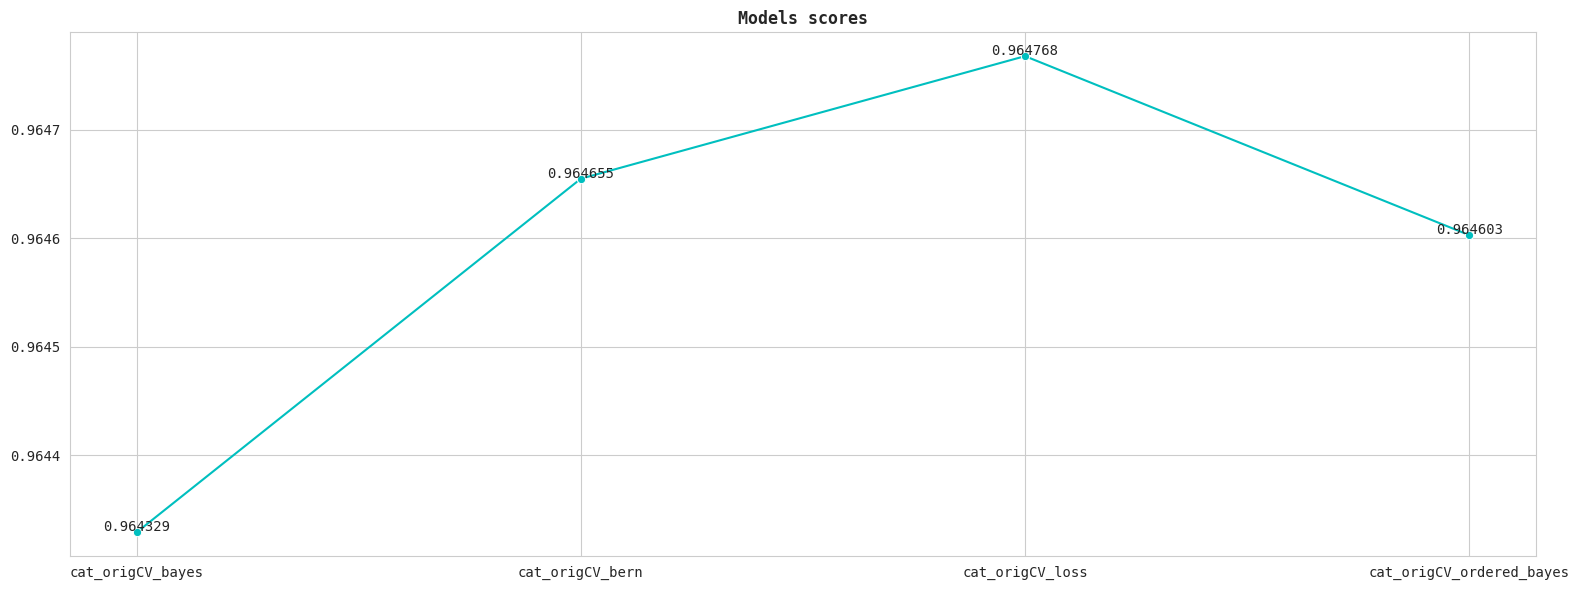

In [37]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 6))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("Models scores", fontweight="semibold")
ax.tick_params('x', rotation=0)
# ax.set_ylim(0.96, 0.968)

add_ = 1e-6
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha="center", va="baseline")

plt.tight_layout()
plt.show()

cat_origCV_bayes_964329 saved!


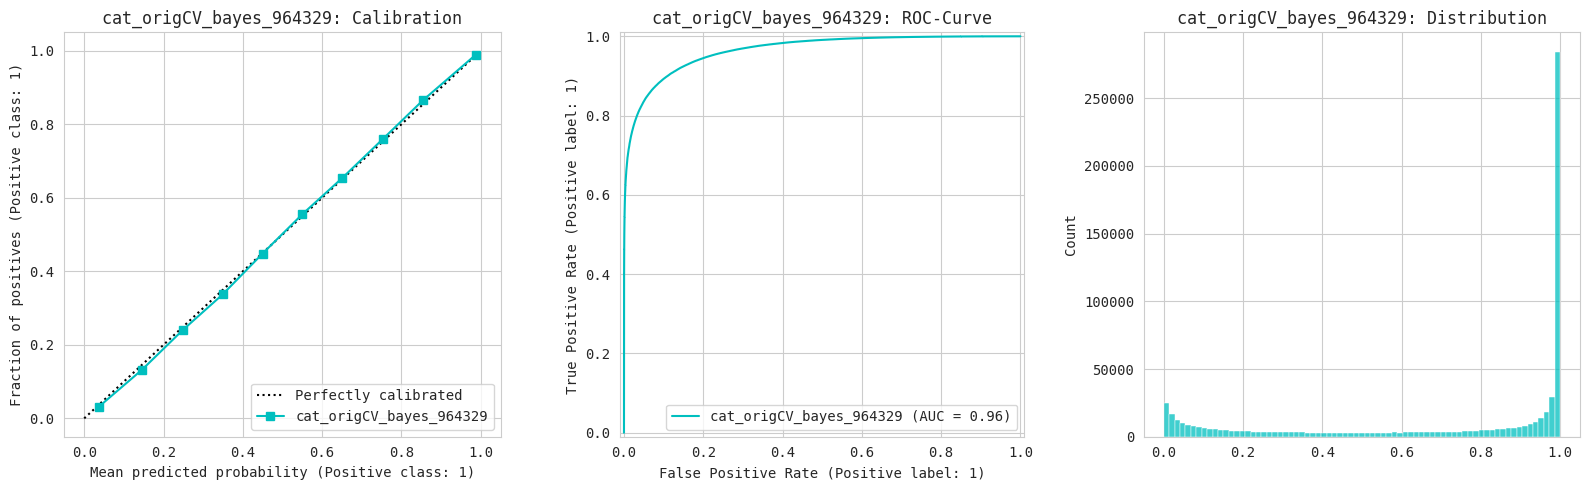


cat_origCV_bern_964655 saved!


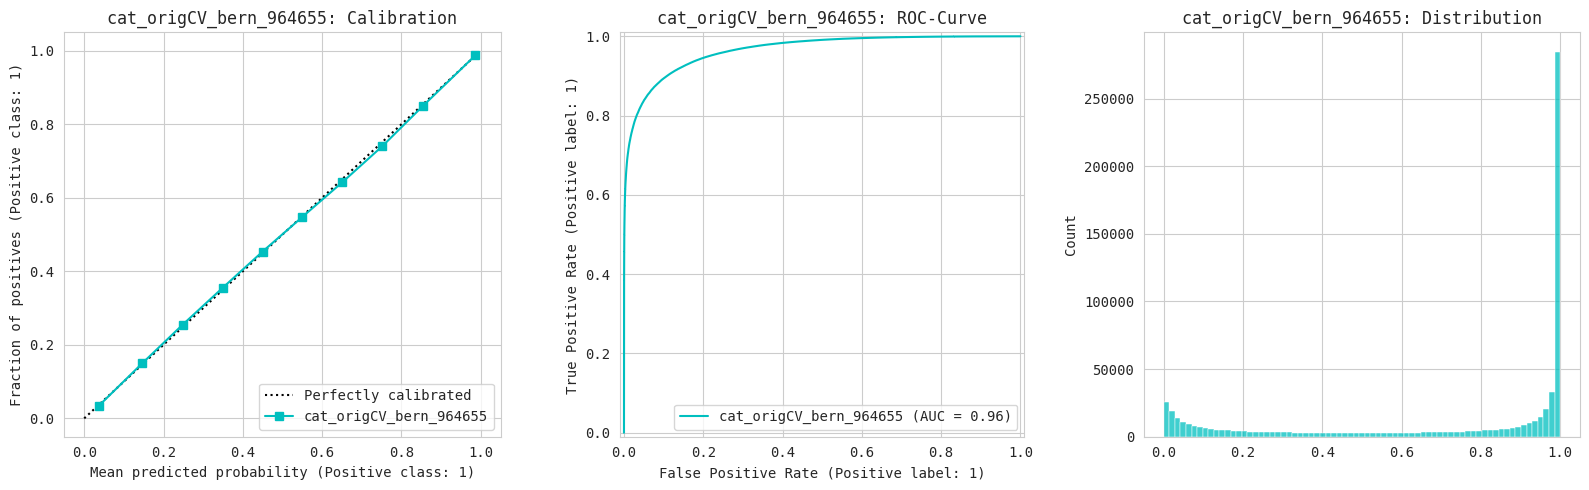


cat_origCV_loss_964768 saved!


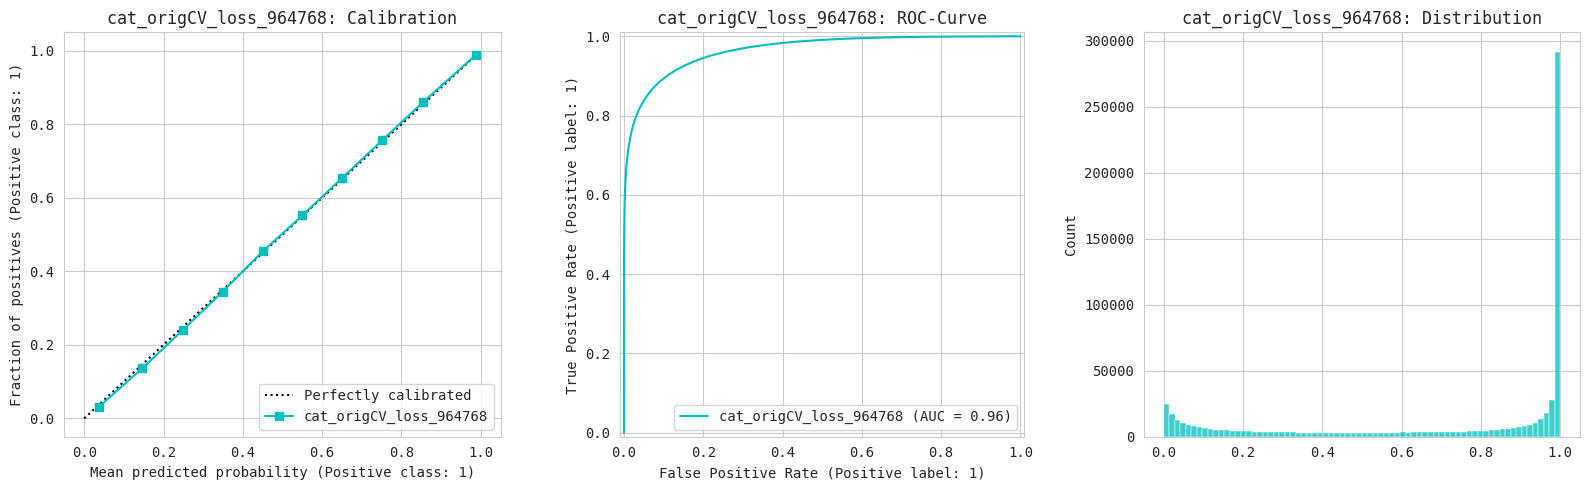


cat_origCV_ordered_bayes_964603 saved!


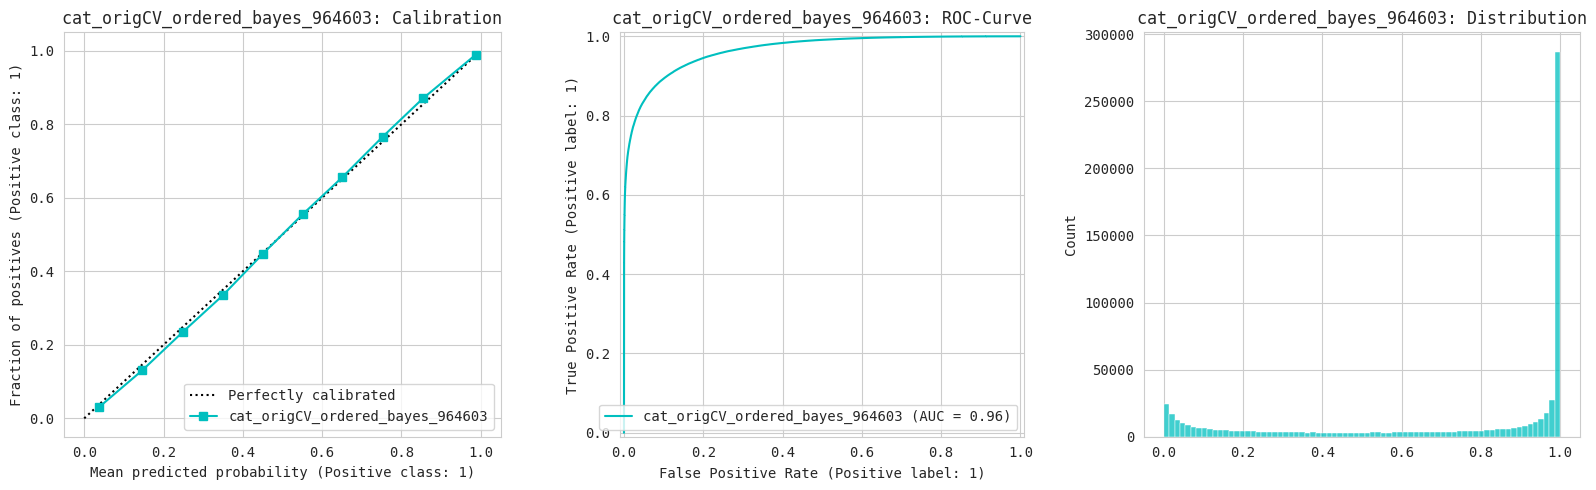

In [38]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [39]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n] = y

cat_origCV_bayes_964329 saved! (296302,)
cat_origCV_bern_964655 saved! (296302,)
cat_origCV_loss_964768 saved! (296302,)
cat_origCV_ordered_bayes_964603 saved! (296302,)


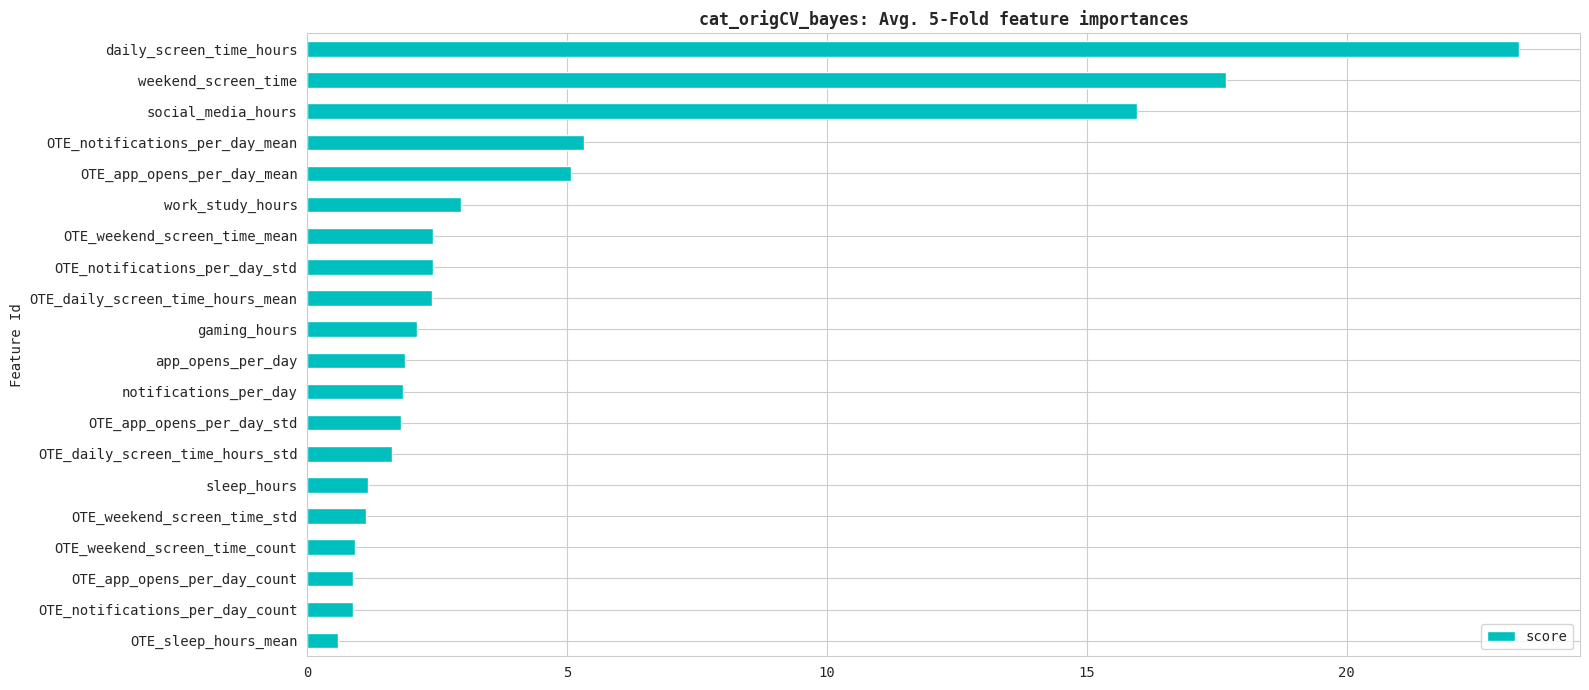

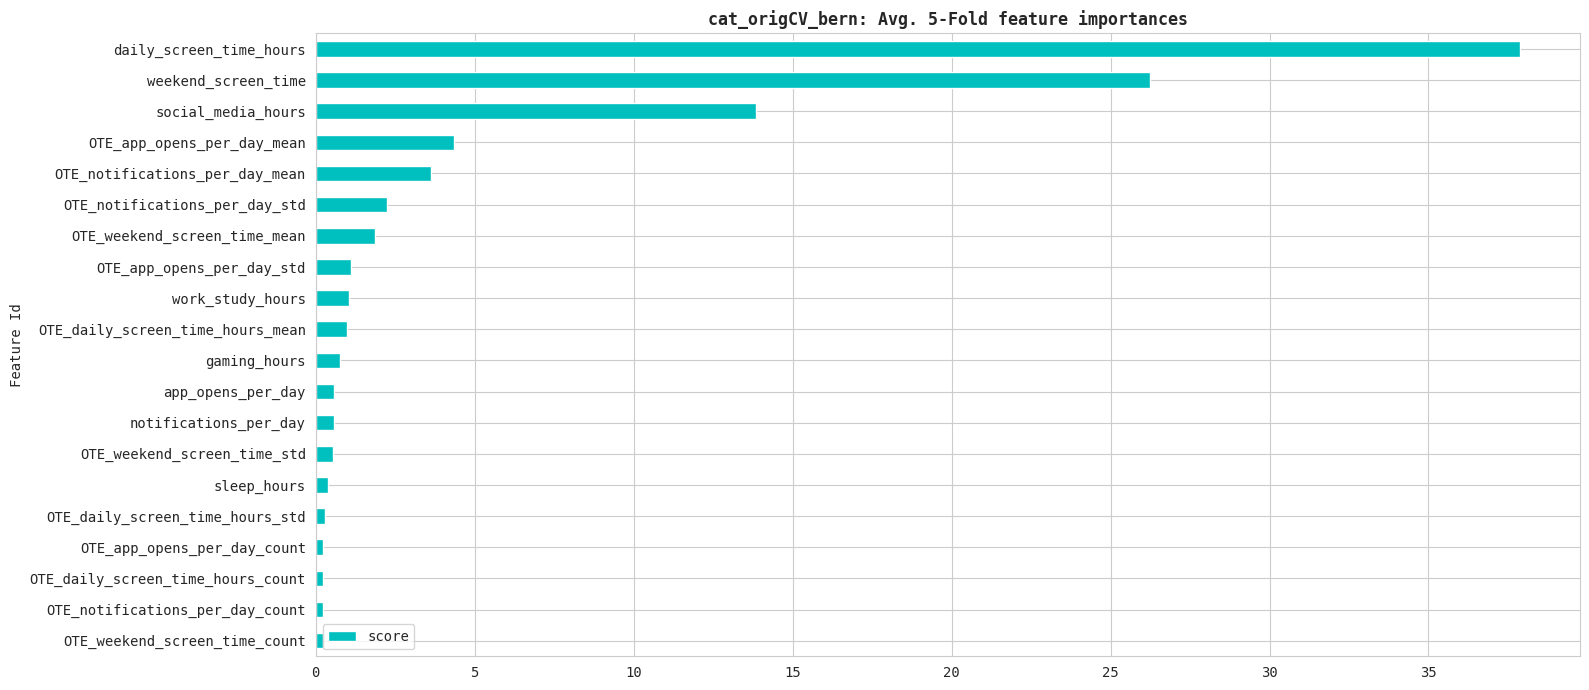

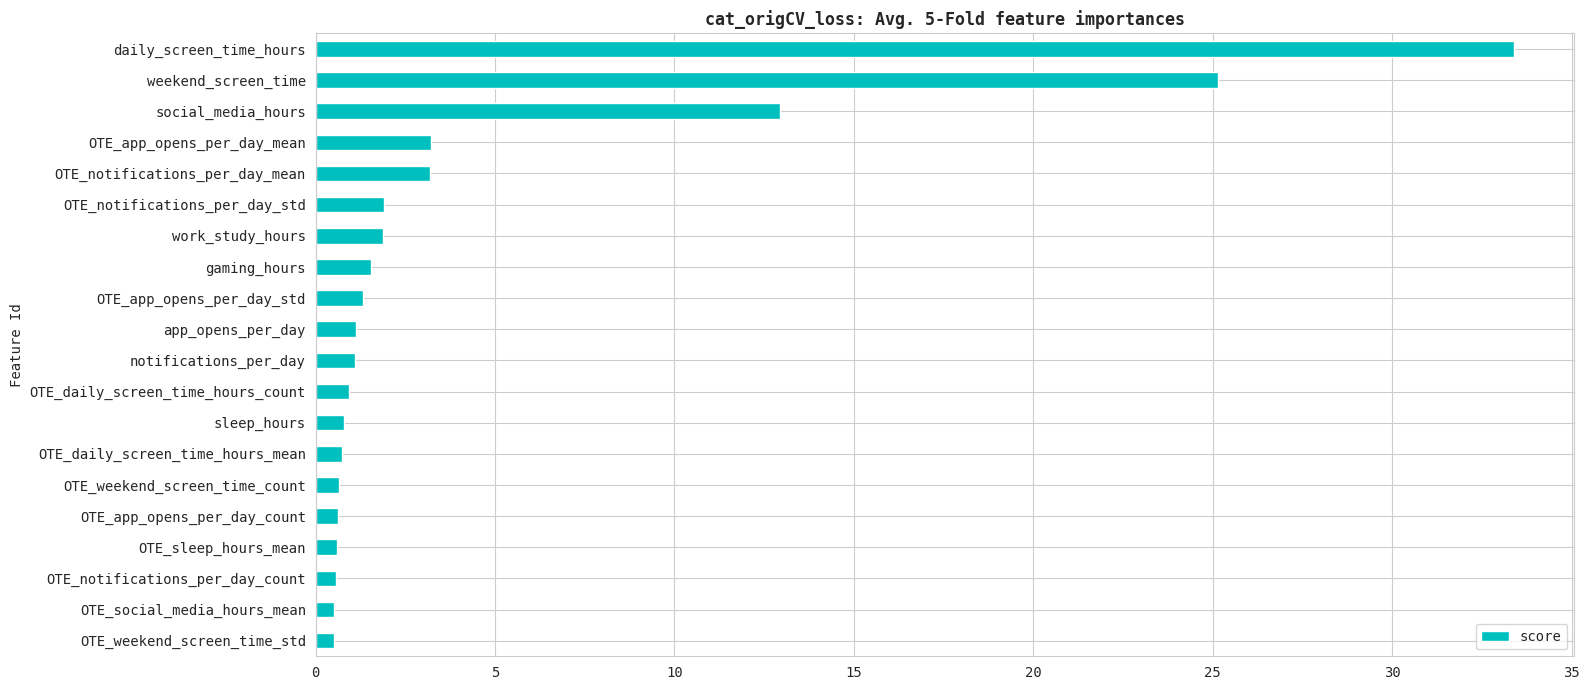

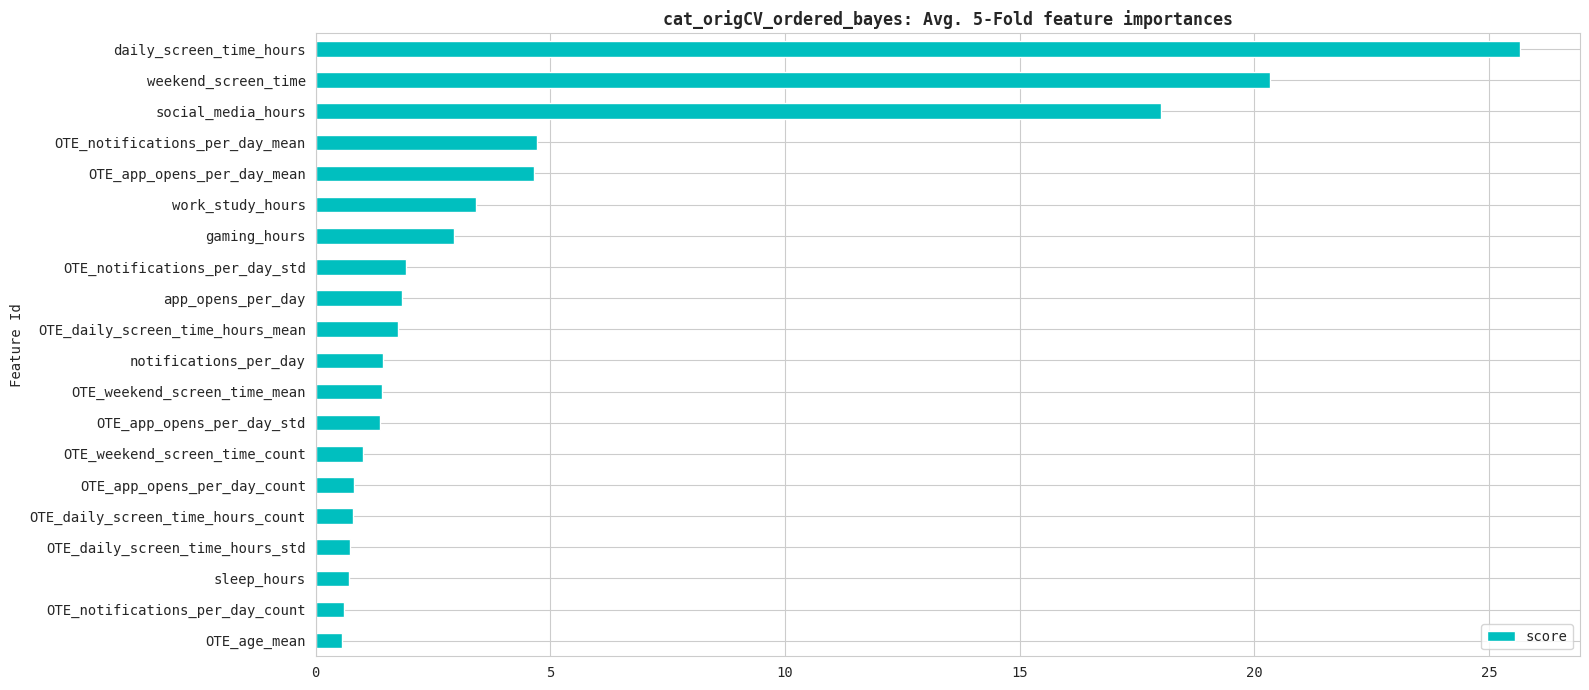

In [40]:
all_feat_importances = {}
all_val_data = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "importances":
            all_feat_importances[k] = y # np.mean(value, axis=0)
        elif x == "val_data":
            all_val_data[k] = y # -> [0] select X_valid, [1] select y_valid

top_n = 20

for i, (m, df) in enumerate(all_feat_importances.items()):
    df_merge = df[0].merge(df[1], how="left", on="Feature Id", suffixes=("_0", ""))\
                    .merge(df[2], how="left", on="Feature Id", suffixes=("_1", ""))\
                    .merge(df[3], how="left", on="Feature Id", suffixes=("_2", ""))\
                    .merge(df[4], how="left", on="Feature Id", suffixes=("_3", "_4"))

    # display(df_merge.head())
    ## -------------------------------------------------------------------------------
    # df_merge["avg_score"] = df_merge.iloc[:, 1:].mean(axis=1)
    # df_merge.sort_values(by="avg_score").iloc[:, :top_n].plot.barh(y="avg_score", x="Feature Id", figsize=(18, 8))
    # plt.tight_layout()
    # plt.show()
    # print()
    ## -------------------------------------------------------------------------------
    df_final = pd.concat([df[0]["Feature Id"], df_merge.drop(columns=["Feature Id"])\
                                                       .mean(axis=1)], axis=1)\
                                                       .rename(columns={0: "score"})\
                                                       .sort_values(by="score")

    ax = df_final.tail(top_n).plot.barh(y="score", x="Feature Id", figsize=(16, 7))
    ax.set_title(f"{m}: Avg. {CFG['FOLDS']}-Fold feature importances", fontweight="semibold")
    plt.tight_layout()
    plt.show()
    print()

In [41]:
pd.DataFrame(model_results)

,cat_origCV_bayes_964329,cat_origCV_bern_964655,cat_origCV_loss_964768,cat_origCV_ordered_bayes_964603
0,0.999620,0.998715,0.998654,0.999594
1,0.962422,0.962704,0.966912,0.956533
2,0.911954,0.888586,0.897938,0.934888
3,0.984129,0.986465,0.994428,0.985970
4,0.996982,0.994387,0.995360,0.995525
...,...,...,...,...
296297,0.999997,0.999992,1.000000,1.000000
296298,0.828295,0.745567,0.844398,0.818862
296299,0.161622,0.136478,0.154263,0.165843
296300,0.780704,0.780301,0.802425,0.813171


In [42]:
# !rm -r /kaggle/working